In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [5]:
df= pd.read_csv('superstoresale.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df['Order Date']= pd.to_datetime(df['Order Date'], format= '%d/%m/%Y')   # convert order date to Pandas datetime format
df['Ship Date']= pd.to_datetime(df['Ship Date'], format= '%d/%m/%Y')     # convert shipping date to pandas datetime format
df.sort_values(by=['Order Date'], ascending=True, inplace=True)          # sorting data by order date
df.set_index('Order Date', inplace=True)                                 # setting order date as the index

In [9]:
print(df.isnull().sum())  # finding missing data

Row ID            0
Order ID          0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [10]:
df[df['Postal Code'].isnull()]  # to find out the city and states that are having null values

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
Order Date,,,,,,,,,,,,,,,,,
2016-11-07,5275,CA-2016-162887,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
2016-11-08,9742,CA-2016-117086,2016-11-12,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.90
2017-01-23,9147,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
2017-01-23,9149,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
2017-01-23,9148,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
2017-04-06,8799,US-2017-150140,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
2018-01-19,9389,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
2018-01-19,9390,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04
2018-01-19,9388,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28


In [25]:
df['Postal Code']= df['Postal Code'].fillna('5401')   # insert the postal code for Burlington 

In [26]:
df.isnull().sum()

Order ID         0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [11]:

top_customers = (df.groupby("Customer Name")['Sales'].sum().sort_values( ascending=False).head(20))  # sortting customers by sales
top_customers= top_customers.round(2) # rounding up the sales up to 2 decimal places
top_customers


Customer Name
Sean Miller           25043.05
Tamara Chand          19052.22
Raymond Buch          15117.34
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.33
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.07
Todd Sumrall          11891.75
Greg Tran             11820.12
Becky Martin          11789.63
Seth Vernon           11470.95
Caroline Jumper       11164.97
Clay Ludtke           10880.55
Maria Etezadi         10663.73
Karen Ferguson        10604.27
Bill Shonely          10501.65
Edward Hooks           9940.38
Name: Sales, dtype: float64

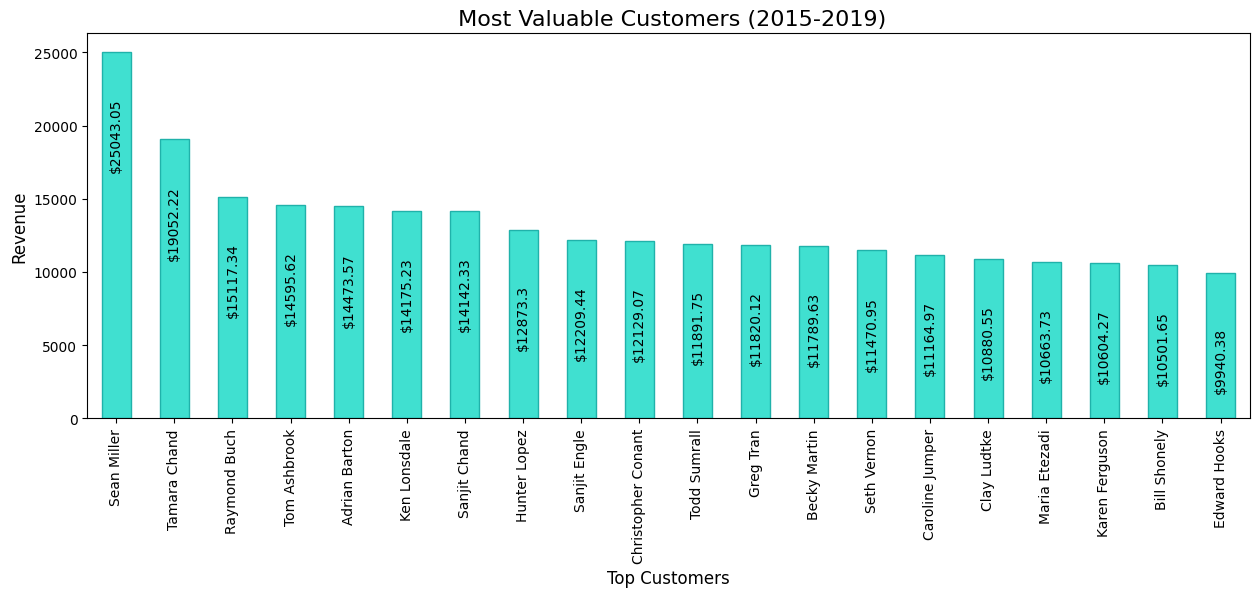

In [63]:
plt.figure(figsize=(15,5))      # setting the width and hight of the figure
top_customers.plot(x='Customer Name',y='Sales', kind='bar',color='turquoise', edgecolor='lightseagreen', linewidth=1)
plt.title(' Most Valuable Customers (2015-2019)', fontsize=16)
plt.xlabel('Top Customers', fontsize=12)   #x axis shows customer names
plt.ylabel('Revenue', fontsize=12)      #y axis shows revenues
plt.xticks(fontsize=10, rotation=90) # shows the customer names horizontal
plt.yticks(fontsize=10)
for k,v in enumerate(top_customers.values):   #To show the exact revenue generated on the figure
     plt.text(k,v-8000,'$'+ str(v), fontsize=10,rotation=90,color='k', horizontalalignment='center');
plt.show()

In [35]:
# Top 20 states which generate the highest revenues

top_states= (df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(20)).round(2)
top_states


State
California        446306.46
New York          306361.15
Texas             168572.53
Washington        135206.85
Pennsylvania      116276.65
Florida            88436.53
Illinois           79236.52
Michigan           76136.07
Ohio               75130.35
Virginia           70636.72
North Carolina     55165.96
Indiana            48718.40
Georgia            48219.11
Kentucky           36458.39
Arizona            35272.66
New Jersey         34610.97
Colorado           31841.60
Wisconsin          31173.43
Tennessee          30661.87
Minnesota          29863.15
Name: Sales, dtype: float64

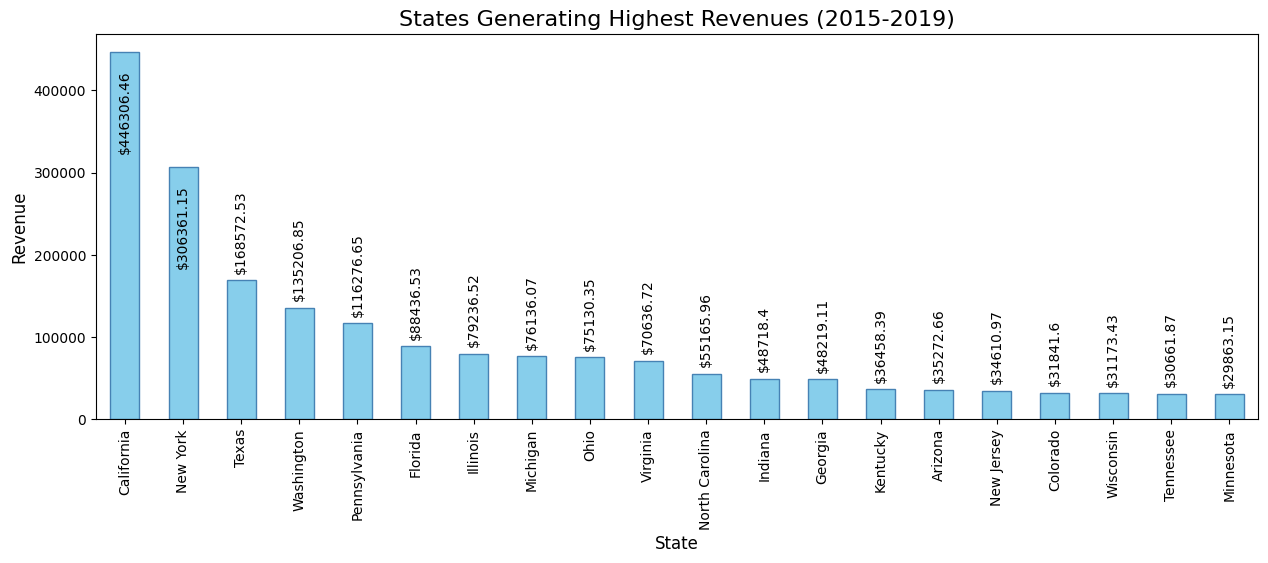

In [72]:
plt.figure(figsize=(15,5))  # setting the width and hight of the figure
plt.title('States Generating Highest Revenues (2015-2019)', fontsize=16)
plt.xlabel('States', fontsize=12)   # x axis shows states
plt.ylabel('Revenue', fontsize=12)  #y axis shows revenues
top_states.plot(x='State', y='Sales', kind='bar', color='skyblue', edgecolor='steelblue')  
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
for k,v in enumerate(top_states.values):   #To show the exact revenue amount generated on the figure
    if v > 170000:
      plt.text(k,v-120000 , '$'+str(v), rotation=90, color='k', ha='center', fontsize=10)
    else:
      plt.text(k,v+12000, '$'+str(v), rotation=90, color='k', ha='center', fontsize=10)
plt.show()

In [77]:
# Top 20 cities which generate the highest revenues

top_cities= (df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)).round(2) # Convert the total_revenue_products from float to int and then to string
top_cities             


City
New York City    252462.55
Los Angeles      173420.18
Seattle          116106.32
San Francisco    109041.12
Philadelphia     108841.75
Houston           63956.14
Chicago           47820.13
San Diego         47521.03
Jacksonville      44713.18
Detroit           42446.94
Springfield       41827.81
Columbus          38662.56
Newark            28448.05
Columbia          25283.32
Jackson           24963.86
Lafayette         24944.28
San Antonio       21843.53
Burlington        21668.08
Arlington         20214.53
Dallas            20127.95
Name: Sales, dtype: float64

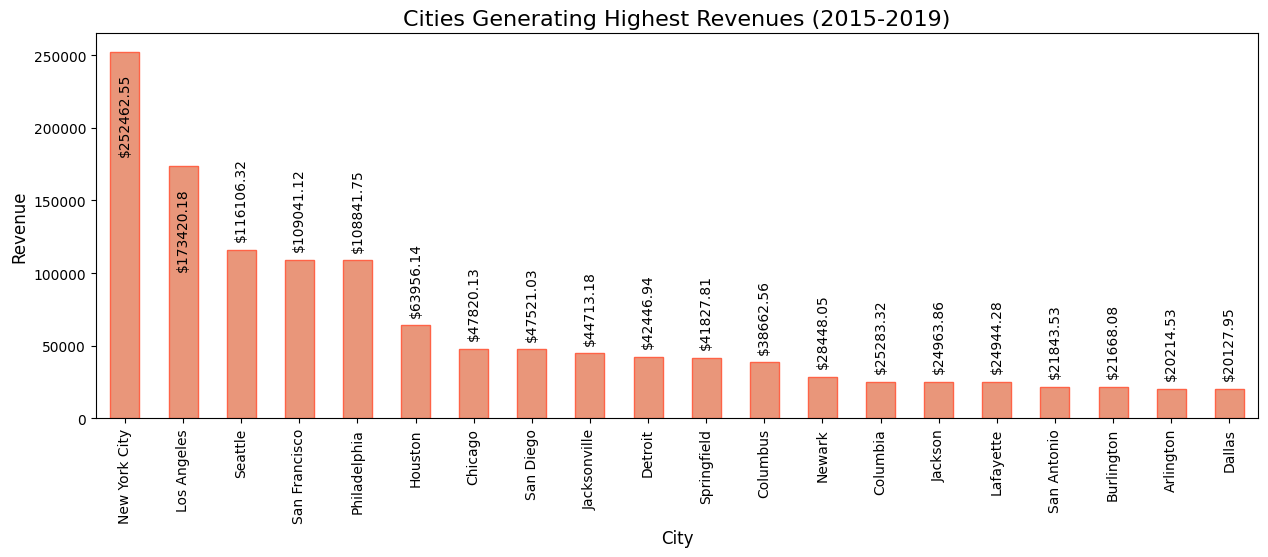

In [99]:
plt.figure(figsize=(15,5))   # setting the width and hight of the figure
plt.title('Cities Generating Highest Revenues (2015-2019)', fontsize=16)
plt.xlabel('Cities', fontsize=12)    # x axis shows cities
plt.ylabel('Revenue', fontsize=12)   # y axis shows revenues
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
top_cities.plot(x='Cities', y='Sales', kind='bar', color='darksalmon', edgecolor='tomato')
for k,v in enumerate(top_cities.values):  #To show the exact revenue amount generated on the figure
    if v > 120000:
       plt.text(k,v-70000, '$'+str(v), rotation=90, color='k', ha='center', fontsize=10)  #to show the revenue on the bar
    else: 
        plt.text(k,v+8000, '$'+str(v), rotation=90, color='k', ha='center',fontsize=10)
plt.show()

In [290]:
# revenue generated by category
top_category= (df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

total_revenue= '$'+ str(int(top_category.sum())) # calculate and Convert the total_revenue from float to int and then to string with adding $ at the beginning
print(top_category)
print('total_revenue: 'f'{total_revenue}')
               

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
total_revenue: $2261536


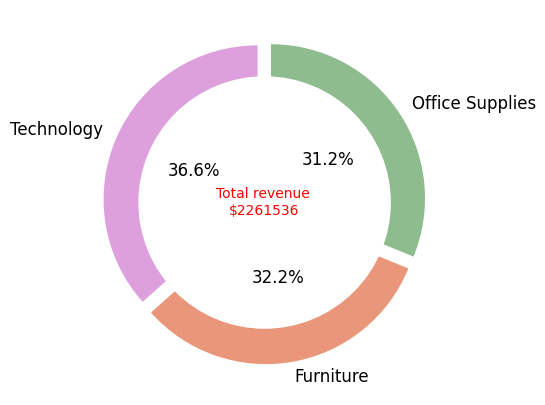

In [307]:
plt.rcParams['figure.figsize']=(13,5)  # width and height of figure 
plt.rcParams['font.size']=12     # Font size is defined
colors=['plum','darksalmon','darkseagreen']
explode = [0.05] * len(top_category)

plt.pie(top_category.values, labels=top_category.index,colors=colors, autopct='%1.1f%%' , startangle=90, explode=explode, labeldistance=1.1, pctdistance=0.45)
centre_circle = plt.Circle((0, 0), 0.82, fc='white')  # draw circle
fig = plt.gcf()
fig.gca().add_artist(centre_circle)    # Adding Circle in Pie chart
plt.text(0,0, 'Total revenue \n' f'{total_revenue}', ha='center', fontsize=10, va='center', color='red')
plt.show()


In [258]:
#products which generate the most revenue
top_products=(df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(8)).round(2) #finding top 8 products 
total_revenue_products= '$'+ str(int(top_products.sum())) # calculate and Convert the total_revenue_products from float to int and then to string with $ at the beginning
print(top_products)
print('total_revenue_product: ' f'{total_revenue_products}') 


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.69
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
Name: Sales, dtype: float64
total_revenue_product: $209624


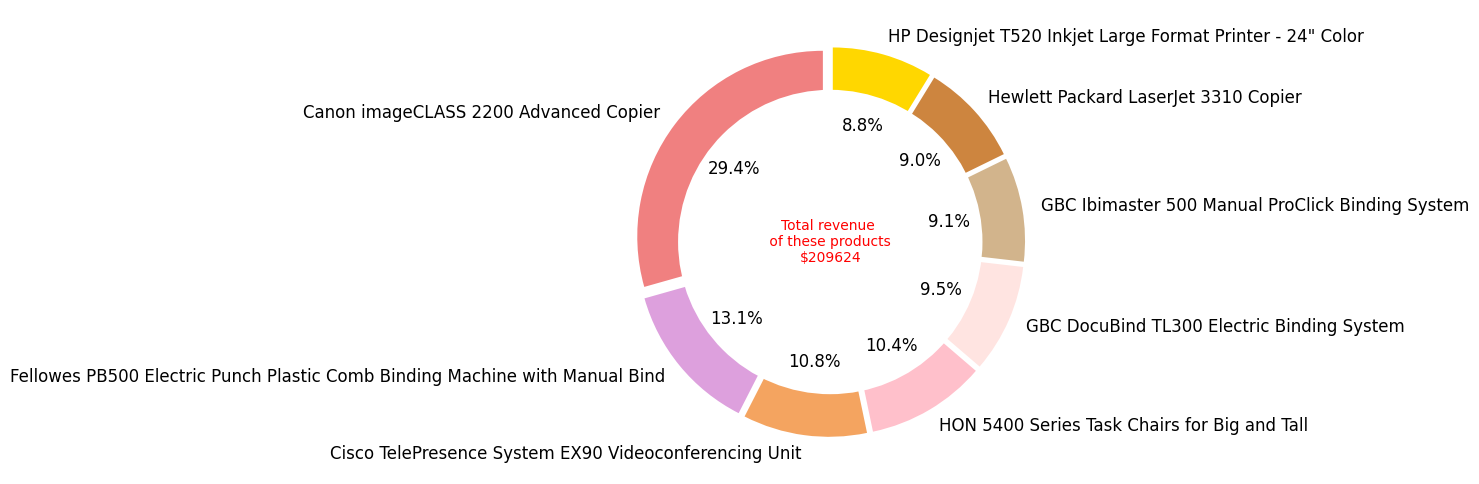

In [299]:
plt.rcParams['figure.figsize']=(13,5)
plt.rcParams['font.size']=12
colors=['lightcoral','plum','sandybrown','pink','mistyrose','tan','peru','gold']
explode = [0.05] * len(top_products)
labels= [ f'Item{i}' for i in range(len(top_products))]
        
plt.pie(top_products.values, labels=top_products.index, colors=colors, autopct='%1.1f%%', startangle=90, explode=explode)
center_circle=plt.Circle((0,0),0.82,fc='white')
fig=plt.gcf()
fig.gca().add_artist(center_circle)
plt.text(0, 0, "Total revenue \n of these products \n" f'{total_revenue_products}', ha='center', va='center', fontsize=10, color='red')
plt.tight_layout()
plt.show()

In [311]:
# the segment which generates highest revenue
top_segment=(df.groupby('Segment')['Sales'].sum().sort_values(ascending=False))
total_segment_revenue= '$'+ str(int(top_segment.sum()))

print(top_segment)
print('total segment revenue: ' f'{total_segment_revenue}')

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64
total segment revenue: $2261536


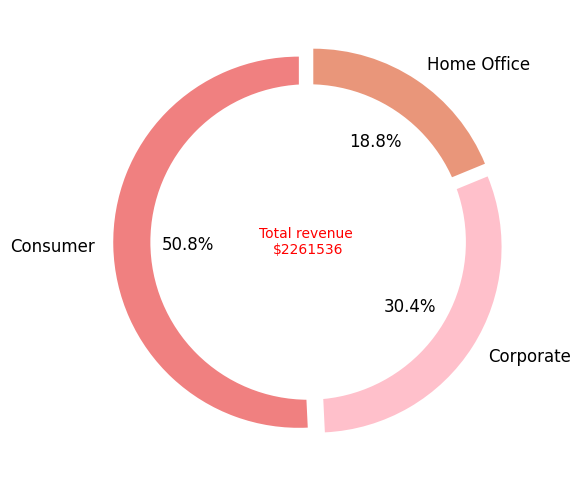

In [336]:
plt.rcParams['figure.figsize']=(13,5)
plt.rcParams['font.size']=12
plt.rcParams['font.weight']=6
colors= ['lightcoral', 'pink','darksalmon']
labels= [f'Item{i}' for i in range (len(top_segment))]

plt.pie(top_segment.values, labels=top_segment.index, explode=explode, startangle=90,colors=colors, autopct='%1.1f%%')
center_circle=plt.Circle((0,0),0.85, fc='white')
fig=plt.gcf()
fig.gca().add_artist(center_circle)
plt.text(0,0, 'Total revenue \n' f'{total_segment_revenue}', color='red', fontsize=10, ha='center', va='center')

plt.tight_layout()
plt.show()

In [356]:
#shipping mode which generates highest revenue
top_shipping= (df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False))
total_shipping_revenue= '$' + str(int(top_shipping.sum()))
print(top_shipping)
print('total shipping revenue: ' f'{total_shipping_revenue}')

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64
total shipping revenue: $2261536


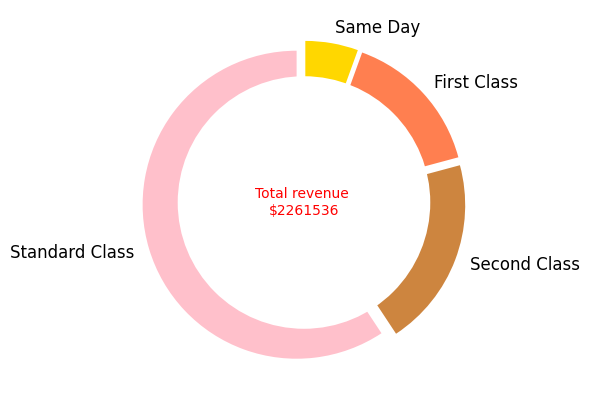

In [359]:
plt.rcParams['figure.figsize']=(13,5)
plt.rcParams['font.size']=12
plt.rcParams['font.weight']=6
colors=['pink','peru','coral','gold']
labels=[ f'Items{i}' for i in range(len(top_shipping))]
explode=[0.05]*len(top_shipping)

plt.pie(top_shipping.values, labels=top_shipping.index, startangle=90, explode=explode, colors=colors)
center_circle=plt.Circle((0,0),0.82, fc='white')
fig=plt.gcf()
fig.gca().add_artist(center_circle)
plt.text(0,0, 'Total revenue \n' f'{total_shipping_revenue}', color='red', ha='center',va='center', fontsize=10)


plt.show()